In [ ]:
import torchvision
from torchvision import datasets
import torch
import matplotlib.pyplot as plt

train_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform= torchvision.transforms.ToTensor(),
    target_transform=None
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform= torchvision.transforms.ToTensor(),
    target_transform=None
)

In [25]:
from rich import print
device = 'cuda' if torch.cuda.is_available() else "cpu"


print(device)

cuda

In [9]:
class_names = train_data.classes

In [ ]:
from torch.utils.data import DataLoader

BATCH_SIZE: int = 32

train_dataloader = DataLoader(
    dataset=train_data,
    batch_size= BATCH_SIZE,
    shuffle= True,
)

test_dataloader = DataLoader(
    dataset=test_data,
    batch_size=BATCH_SIZE,
    shuffle=False
)

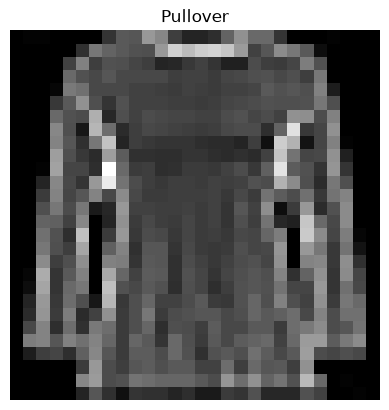

In [16]:
torch.manual_seed(42)

for train_features_batch, train_labels_batch in train_dataloader:
    random_idx = torch.randint(0, len(train_features_batch), size=(1,)).item()
    img, label = train_features_batch[random_idx], train_labels_batch[random_idx]
    plt.imshow(img.squeeze(dim=0), cmap='gray')
    plt.axis(False)
    plt.title(class_names[label])
    break
    

In [34]:
from torch import nn
class FashionMNSITModelV0(nn.Module):

    def __init__(self, 
                 input_shape: int,
                 hidden_layer1: int,
                 output_shape: int
                 ):
        super().__init__()

        self.layers = nn.Sequential(
            nn.Flatten(),

            nn.Linear(
                in_features= input_shape, 
                out_features= hidden_layer1,
            ),

            # nn.ReLU(),

            nn.Linear(
                in_features= hidden_layer1,
                out_features= output_shape 
            )
        )

    def forward(self, x: torch.Tensor):
        return self.layers(x)

model_0 = FashionMNSITModelV0(
    input_shape= train_data.data.shape[1] * train_data.data.shape[2],
    hidden_layer1= 10,
    output_shape= len(train_data.classes),
).to(device)



In [35]:
model_0

FashionMNSITModelV0(
  (layers): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
  )
)

In [9]:


LEARING_RATE = 0.01
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(
    params=model_0.parameters(),
    lr= LEARING_RATE
)

In [ ]:
from torchmetrics import Accuracy
acc_fn = Accuracy(
    task= "multiclass",
    num_classes=len(train_data.classes)
)

In [ ]:
from tqdm.auto import tqdm

torch.manual_seed(42)

epochs = 3

for epoch in tqdm(range(epochs)):

    train_loss, train_acc = 0.0, 0.0
    for batch, (X, y) in enumerate(train_dataloader):
        model_0.train()

        X = X.to(device)
        y = y.to(device)

        y_logits = model_0(X)

        train_acc += acc_fn(y_logits.argmax(dim=1), y)

        loss = loss_fn(y_logits, y)


        optimizer.zero_grad()

        train_loss += loss

        loss.backward()

        optimizer.step()

        if batch % 400 == 0:
            print(f"Batch no. {batch} , looked at {batch * len(X)}/{len(train_data)}")


    # Taking the average
    train_loss /= len(train_dataloader)
    train_acc /= len(train_dataloader)


    test_loss, test_acc = 0.0, 0.0

    model_0.eval()

    with torch.inference_mode():

        for X_test , y_test in test_dataloader:


            X_test = X_test.to(device)
            y_test = y_test.to(device)

            test_logits = model_0(X_test)

            test_loss += loss_fn(test_logits, y_test)

            test_acc += acc_fn(test_logits.argmax(dim=1), y_test)


        test_loss /= len(test_dataloader)

        test_acc /= len(test_dataloader)


    print(f"Train Loss: {train_loss:.4f} | Test Loss: {test_loss:.4f}")
    print(f"Train Accuracy: {train_acc:.2%} | Test Accuracy: {test_acc:.2%}")
    print("[green]#[/green]" * 20)



  0%|          | 0/3 [00:00<?, ?it/s]

Batch no. 0 , looked at 0/60000

Batch no. 400 , looked at 12800/60000

Batch no. 800 , looked at 25600/60000

Batch no. 1200 , looked at 38400/60000

...

Batch no. 0 , looked at 0/60000

Batch no. 400 , looked at 12800/60000

Batch no. 800 , looked at 25600/60000

 33%|███▎      | 1/3 [00:35<01:10, 35.17s/it]


KeyboardInterrupt: 